# Clase 10 — Analizando el catálogo de Netflix

En este ejercicio asumirás el rol de un **Data Analyst** dentro de Netflix. El equipo de negocio quiere entender mejor cómo está distribuido el catálogo de la plataforma para tomar decisiones sobre futuras inversiones en contenido.

Para ello deberás utilizar las herramientas aprendidas en esta clase:

- `groupby()`
- funciones de agregación
- `agg()`
- `pivot_table()`
- `unstack()`
- gráficos con Pandas y Matplotlib

> No utilices bucles (`for`) para resolver los ejercicios.


## Parte 1: Exploración del dataset

Antes de comenzar el análisis responde:

1. Carga el dataset.
2. Muestra las primeras filas.
3. ¿Cuántas filas y columnas posee?
4. ¿Qué tipo de dato tiene cada columna?
5. ¿Existen valores nulos?
6. ¿Qué columnas presentan mayor cantidad de valores faltantes?

In [170]:
import pandas as pd

df = pd.read_csv("netflix_data.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [169]:
df.shape

(8807, 12)

In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Parte 2: Agrupaciones

### Ejercicio 1 - ¿Cuántos títulos existen por país?

Ordena el resultado de mayor a menor.


In [167]:
titulos_pais = df.groupby("country")["title"].count().sort_values(ascending=False)
titulos_pais

country
United States          2818
India                   972
United Kingdom          419
Japan                   245
South Korea             199
                       ... 
Australia, Iraq           1
Venezuela                 1
Venezuela, Colombia       1
West Germany              1
, South Korea             1
Name: title, Length: 748, dtype: int64

### Ejercicio 2 - ¿Cuántas películas y cuántas series tiene Netflix?

In [166]:
total_peliculas_series = df.groupby(["type"])["type"].count()
total_peliculas_series


type
Movie      6131
TV Show    2676
Name: type, dtype: int64

### Ejercicio 3 - ¿Cuántos títulos fueron lanzados cada año?

Ordena el resultado cronológicamente.


In [165]:
titulos_anios = df.groupby("release_year")["release_year"].count()
titulos_anios

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: release_year, Length: 74, dtype: int64

### Ejercicio 4 - ¿Cuál es la clasificación por edades más frecuente?

Por ejemplo:

- TV-MA
- TV-14
- PG
- R

In [164]:
clasificacion_edad = df["rating"].value_counts()
clasificacion_edad

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

### Ejercicio 5 - Obtén para cada tipo de contenido (Movie y TV Show):

- cantidad de títulos
- año promedio de lanzamiento
- año más reciente
- año más antiguo

> Utiliza **agg()**.

In [163]:
resultado = df.groupby("type").agg({
    "title": "count",
    "release_year": ["mean", "max", "min"]
})
resultado.reset_index()

type title release_year            
           count         mean   max   min
0    Movie  6131  2013.121514  2021  1942
1  TV Show  2676  2016.605755  2021  1925

## Parte 3: Agrupaciones múltiples

### Ejercicio 6 - Obtén la cantidad de títulos para cada combinación.

Agrupa por:

- país
- tipo de contenido

In [162]:
resultado = df.groupby(["country","type"]).agg({
    "title": "count",
})
resultado.reset_index()

,country,type,title
0,", France, Algeria",Movie,1
1,", South Korea",TV Show,1
2,Argentina,Movie,38
3,Argentina,TV Show,18
4,"Argentina, Brazil, France, Poland, Germany, De...",Movie,1
...,...,...,...
842,Venezuela,Movie,1
843,"Venezuela, Colombia",Movie,1
844,Vietnam,Movie,7
845,West Germany,Movie,1


### Ejercicio 7 - Convierte el resultado anterior en una tabla donde:

- las filas sean los países
- las columnas sean Movie y TV Show

> Utiliza **unstack()**.

In [161]:
resultado = df.groupby(["country","type"]).agg({
    "title": "count"})
resultado = resultado.unstack()
resultado = resultado.reset_index()
resultado

country title        
type                                                    Movie TV Show
0                                     , France, Algeria   1.0     NaN
1                                         , South Korea   NaN     1.0
2                                             Argentina  38.0    18.0
3     Argentina, Brazil, France, Poland, Germany, De...   1.0     NaN
4                                      Argentina, Chile   2.0     NaN
..                                                  ...   ...     ...
743                                           Venezuela   1.0     NaN
744                                 Venezuela, Colombia   1.0     NaN
745                                             Vietnam   7.0     NaN
746                                        West Germany   1.0     NaN
747                                            Zimbabwe   1.0     NaN

[748 rows x 3 columns]

## Parte 4: Tablas dinámicas

### Ejercicio 8 - Construye una tabla dinámica donde:

- filas → país
- columnas → tipo de contenido
- valores → cantidad de títulos

In [160]:
tabla = df.pivot_table(
    values   = "title",
    index    = "country",
    columns  = "type",
    aggfunc  = "count",
    fill_value = 0,
)
tabla

type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,7,0


### Ejercicio 9 - Construye otra tabla dinámica donde:

- filas → clasificación por edades
- columnas → tipo de contenido
- valores → cantidad de títulos

In [159]:
tabla = df.pivot_table(    
    values   = "show_id",
    index    = "rating",
    columns  = "type",
    aggfunc  = "count",
)
tabla

type,Movie,TV Show
rating,,
66 min,1.0,NaN
74 min,1.0,NaN
84 min,1.0,NaN
G,41.0,NaN
NC-17,3.0,NaN
NR,75.0,5.0
PG,287.0,NaN
PG-13,490.0,NaN
R,797.0,2.0


### Ejercicio 10 - Modifica la tabla dinámica para que los valores faltantes aparezcan como **0**.

In [158]:
df.pivot_table(    
    values   = "show_id",
    index    = "rating",
    columns  = "type",
    aggfunc  = "count",
    fill_value = 0,
)
tabla

type,Movie,TV Show,Total
country,,,
United States,2058,760,2818
India,893,79,972
United Kingdom,206,213,419
Japan,76,169,245
South Korea,41,158,199


## Parte 5: Visualización

### Ejercicio 11 - Genera un gráfico de barras con el **Top 10 países con mayor cantidad de títulos**.

El gráfico debe incluir:

- título
- tamaño de figura
- etiquetas rotadas
- eje Y con nombre


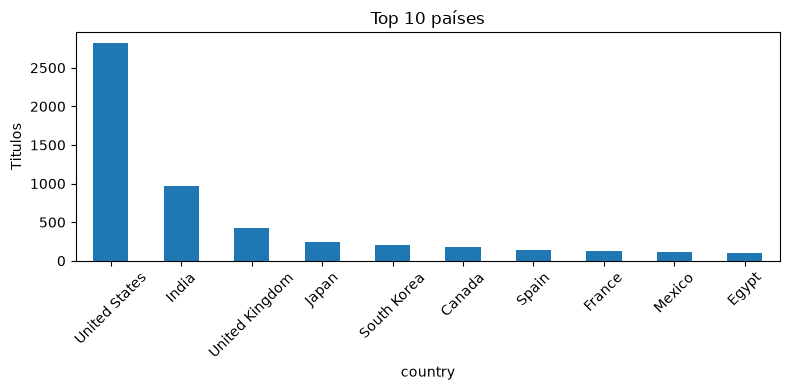

In [157]:
import matplotlib.pyplot as plt

paises_ordenados = df.groupby("country")["title"].count().sort_values(ascending=False)
serie_ordenada = paises_ordenados.head(10)

serie_ordenada.plot(kind="bar", figsize=(8, 4), title="Top 10 países")
plt.ylabel("Titulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ejercicio 12 - Genera un gráfico de barras mostrando la cantidad de:

- Movies
- TV Shows

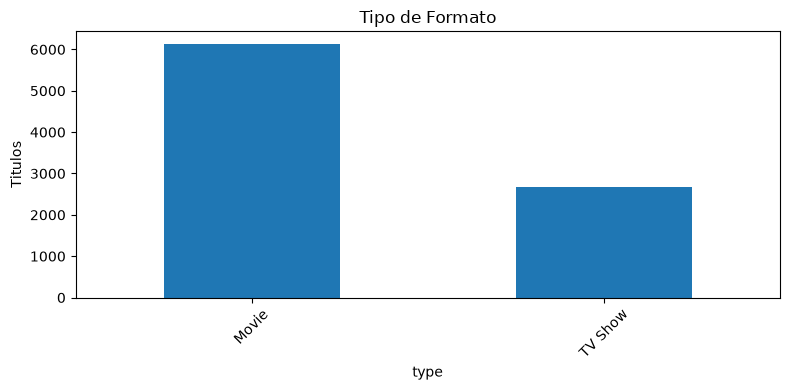

In [156]:
import matplotlib.pyplot as plt

tipo_formato = df.groupby("type")["type"].count()

tipo_formato.plot(kind="bar", figsize=(8, 4), title="Tipo de Formato")
plt.ylabel("Titulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ejercicio 13 - Utilizando la tabla dinámica, crea un gráfico de barras agrupadas que compare películas y series por país.


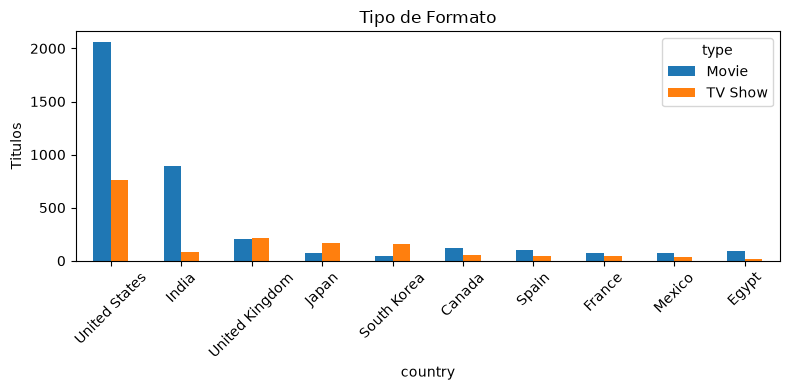

In [176]:
import matplotlib.pyplot as plt

tabla["Total"]= tabla["Movie"] + tabla["TV Show"]
tabla_paises = tabla.sort_values(by='Total', ascending=False)
tabla_paises = tabla_paises.head(10)
ordenado_principales = tabla_paises[["Movie", "TV Show"]]

ordenado_principales.plot(kind="bar", figsize=(8, 4), title="Tipo de Formato")
plt.ylabel("Titulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Parte 6: Análisis

Redacta al menos **cinco insights** basados en el análisis realizado. Algunas preguntas que puedes responder son:

- ¿Qué país domina el catálogo?
- ¿Netflix posee más películas o más series?
- ¿Qué clasificación por edades es la más utilizada?
- ¿Existen países donde predominen las series?
- ¿Qué tendencia observas respecto al año de lanzamiento de los contenidos?

Justifica cada respuesta utilizando los datos obtenidos.

In [ ]:
# tu código acá

## Desafío

Netflix desea aumentar su presencia en Latinoamérica. Analiza únicamente los siguientes países:

- Argentina
- Brasil
- Chile
- Colombia
- México
- Perú

Responde:

1. ¿Cuál aporta mayor cantidad de contenido?
2. ¿Predominan las películas o las series?
3. ¿Qué clasificación por edades es la más común?
4. Genera un gráfico comparativo.
5. Escribe una breve recomendación para el director regional de Netflix basada en tus resultados.


In [ ]:
# tu código acá